# This notebook walks through core NumPy and Matplotlib examples.

In [2]:
import numpy as np
from scipy import stats
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.image import imread

In [3]:
# Set plotting defaults
plt.rcParams['figure.figsize'] = (6,4)
plt.rcParams['grid.alpha'] = 0.3

## 1. Basic NumPy Operations

In [4]:
# Creating arrays and simple arithmetic
arr = np.array([1,2,3,4,5])
print("arr:", arr)
arr1 = np.array([10,20,30])
arr2 = np.array([1,2,3])
print("add:", arr1 + arr2)
print("mul:", arr1 * arr2)
print("range:", np.arange(10))

arr: [1 2 3 4 5]
add: [11 22 33]
mul: [10 40 90]
range: [0 1 2 3 4 5 6 7 8 9]


## 2. Array Dimensions (0D–3D)

In [5]:
# 0D (scalar)
x1 = np.array(10)
print(x1, x1.ndim, x1.shape)


10 0 ()


In [6]:
# 1D (vector)
x2 = np.array([10,20,30,40])
print(x2, x2.ndim, x2.shape)

[10 20 30 40] 1 (4,)


In [7]:
# 2D (matrix)
x3 = np.array([[1,2,3],[4,5,6]])
print(x3, x3.ndim, x3.shape)

[[1 2 3]
 [4 5 6]] 2 (2, 3)


In [8]:
# 3D (tensor)
a3 = np.array([[[1,2],[3,4]],[[5,6],[7,8]],[[9,10],[11,12]]])
print(a3, a3.ndim, a3.shape)

[[[ 1  2]
  [ 3  4]]

 [[ 5  6]
  [ 7  8]]

 [[ 9 10]
  [11 12]]] 3 (3, 2, 2)


## 3. Reshaping Arrays

In [9]:
b = np.arange(1,13)
print("orig shape", b.shape)

orig shape (12,)


In [10]:
# 1D → 2D, 3D, 4D, 5D
for shape in [(2,6),(2,3,2),(2,3,2,1),(2,1,3,2,1)]:
    c = b.reshape(shape)
    print(shape, c.shape)
    print(c, '\n' + '*'*30)


(2, 6) (2, 6)
[[ 1  2  3  4  5  6]
 [ 7  8  9 10 11 12]] 
******************************
(2, 3, 2) (2, 3, 2)
[[[ 1  2]
  [ 3  4]
  [ 5  6]]

 [[ 7  8]
  [ 9 10]
  [11 12]]] 
******************************
(2, 3, 2, 1) (2, 3, 2, 1)
[[[[ 1]
   [ 2]]

  [[ 3]
   [ 4]]

  [[ 5]
   [ 6]]]


 [[[ 7]
   [ 8]]

  [[ 9]
   [10]]

  [[11]
   [12]]]] 
******************************
(2, 1, 3, 2, 1) (2, 1, 3, 2, 1)
[[[[[ 1]
    [ 2]]

   [[ 3]
    [ 4]]

   [[ 5]
    [ 6]]]]



 [[[[ 7]
    [ 8]]

   [[ 9]
    [10]]

   [[11]
    [12]]]]] 
******************************


## 4. Solving Linear Systems

In [11]:
# 2×2 system
A = np.array([[4,3],[-5,9]])
B = np.array([20,96])
print("2x2 solution", np.linalg.solve(A,B))

2x2 solution [-2.11764706  9.49019608]


In [12]:
# 3×3 system
S = np.array([[12,14,-10],[20,-15,11],[15,-4,5]])
T = np.array([20,21,12])
print("3x3 solution", np.linalg.solve(S,T))

3x3 solution [ 1.31798246 -1.89254386 -3.06798246]


## 5. Matrix Properties

In [13]:
X = np.array([[1,2,-3j],[-4,5,6],[7,8j,9]])
print("rank", np.linalg.matrix_rank(X))
print("trace", np.trace(X))
print("determinant", np.linalg.det(X))
print("inverse:\n", np.linalg.inv(X))

rank 3
trace (15+0j)
determinant (104.99999999999999+56.99999999999999j)
inverse:
 [[ 0.13934426-0.53278689j  0.04413619-0.02395965j  0.1481715 +0.06242119j]
 [ 0.57377049-0.31147541j  0.15006305+0.1185372j   0.0037831 +0.11223203j]
 [-0.3852459 -0.09562842j  0.07103825-0.1147541j   0.09562842-0.05191257j]]


## 6. Eigen & Transpose

In [14]:
X2 = np.array([[1,2],[3,4]])
print("X^2:\n", np.linalg.matrix_power(X2,2))
print("X^3:\n", np.linalg.matrix_power(X2,3))
eigvals, eigvecs = np.linalg.eig(X2)
print("eigenvalues", eigvals)
print("eigenvectors:\n", eigvecs)
print("transpose:\n", X2.T)

X^2:
 [[ 7 10]
 [15 22]]
X^3:
 [[ 37  54]
 [ 81 118]]
eigenvalues [-0.37228132  5.37228132]
eigenvectors:
 [[-0.82456484 -0.41597356]
 [ 0.56576746 -0.90937671]]
transpose:
 [[1 3]
 [2 4]]


## 7. Descriptive Statistics

In [16]:
peed = [11,22,33,44,55,66,77,88,99,100]
print("mean", np.mean(speed))
print("median", np.median(speed))
mode_res = stats.mode(speed, keepdims=True)
mode_v = mode_res.mode[0]
print("mode", mode_v)
print("std", np.std(speed))
print("var", np.var(speed))
print("75th pct", np.percentile(speed,75))

mean 59.5
median 60.5
mode 11
std 30.137186331839274
var 908.25
75th pct 85.25


## 8. Random Distributions & Histograms

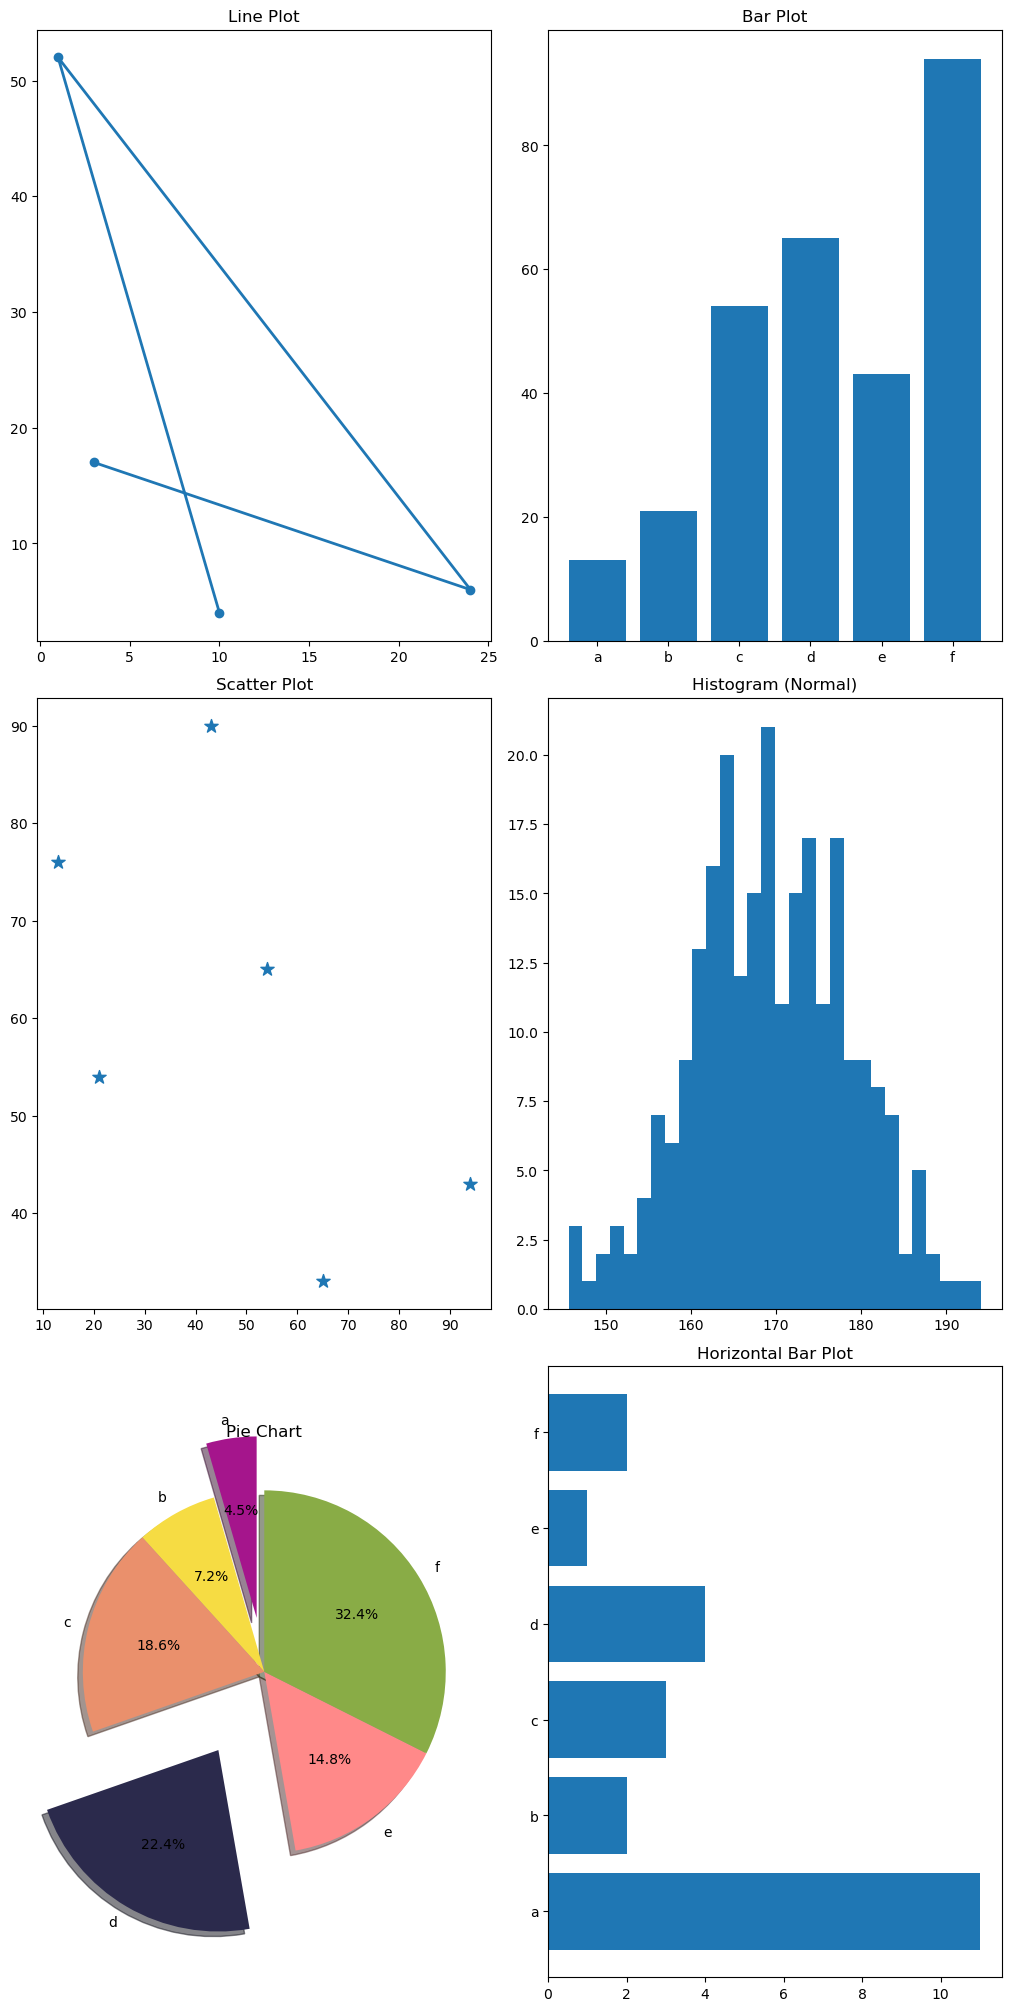

In [18]:
# Create 3x2 grid of diverse plots
fig, axes = plt.subplots(3, 2, figsize=(10, 20), constrained_layout=True)
axes = axes.flatten()

# 1. Line Plot
x = np.array([10, 1, 24, 3])
y = np.array([4, 52, 6, 17])
axes[0].plot(x, y, marker='o', linestyle='-', linewidth=2)
axes[0].set_title('Line Plot')

# 2. Bar Plot
x1 = np.array([13, 21, 54, 65, 43, 94])
ao = np.array(['a','b','c','d','e','f'])
axes[1].bar(ao, x1)
axes[1].set_title('Bar Plot')

# 3. Scatter Plot
x2 = np.array([13, 21, 54, 65, 43, 94])
y2 = np.array([76, 54, 65, 33, 90, 43])
axes[2].scatter(x2, y2, marker='*', s=100)
axes[2].set_title('Scatter Plot')

# 4. Histogram (Normal Dist.)
y3 = np.random.normal(170, 10, 250)
axes[3].hist(y3, bins=30)
axes[3].set_title('Histogram (Normal)')

# 5. Pie Chart
x4 = np.array([13,21,54,65,43,94])
axes[4].pie(x4, labels=['a','b','c','d','e','f'], autopct='%2.1f%%',
            colors=['#A5158C','#F6DC43','#EA906C','#2B2A4C','#FF8989','#89AC46'],
            explode=[0.3,0,0,0.5,0,0], shadow=True, startangle=90)
axes[4].set_title('Pie Chart')

# 6. Horizontal Bar Plot
x5 = np.array([11,2,3,4,1,2])
aa5 = np.array(['a','b','c','d','e','f'])
axes[5].barh(aa5, x5)
axes[5].set_title('Horizontal Bar Plot')

plt.show()

## 9. Trig, Logarithmic, Exponential, and Linear Functions

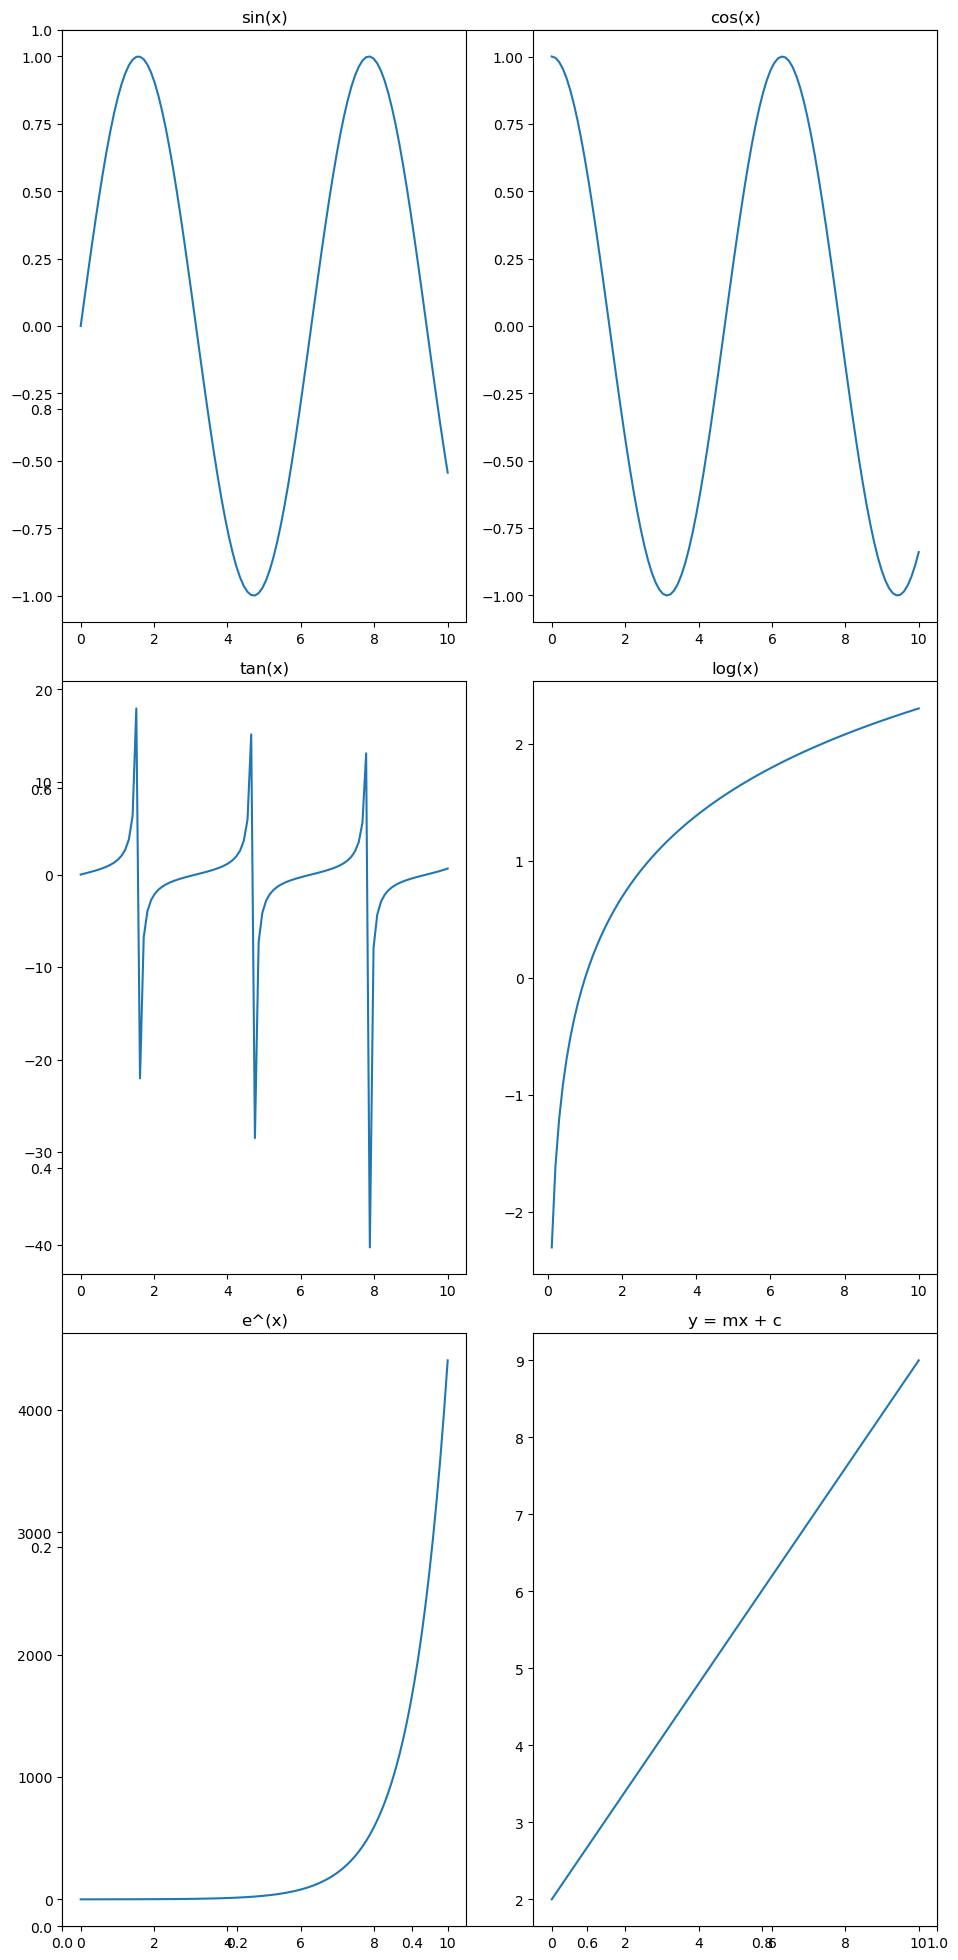

In [19]:
# Create the figure with a specific size
plt.subplots(figsize=(10, 20))
# 1. Sin function
x = np.linspace(0, 10, 100)
plt.subplot(3, 2, 1)  
plt.plot(x, np.sin(x))
plt.title('sin(x)')
# 2. Cos function
x = np.linspace(0, 10, 100)
plt.subplot(3, 2, 2)  
plt.plot(x, np.cos(x))
plt.title('cos(x)')
# 3. Tan function
x = np.linspace(0, 10, 100)
plt.subplot(3, 2, 3)  
plt.plot(x, np.tan(x))
plt.title('tan(x)')
# 4. Logarithmic function
x = np.linspace(0.1, 10, 100)  # Start at 0.1 to avoid log(0)
plt.subplot(3, 2, 4)  
plt.plot(x, np.log(x))
plt.title('log(x)')
# 5. Exponential function (e^x)
x = np.linspace(0, 10, 100)
a = 0.2
plt.subplot(3, 2, 5)  
plt.plot(x, a * np.exp(x))
plt.title('e^(x)')
# 6. Linear equation y = mx + c
x = np.linspace(0, 10, 100)
n = 0.7  # slope
c = 2    # y-intercept
y = (x * n) + c
plt.subplot(3, 2, 6)  
plt.plot(x, y)
plt.title('y = mx + c')
# Show the plots
plt.tight_layout()  # To ensure everything fits without overlap
plt.show()



## 10. Heatmap

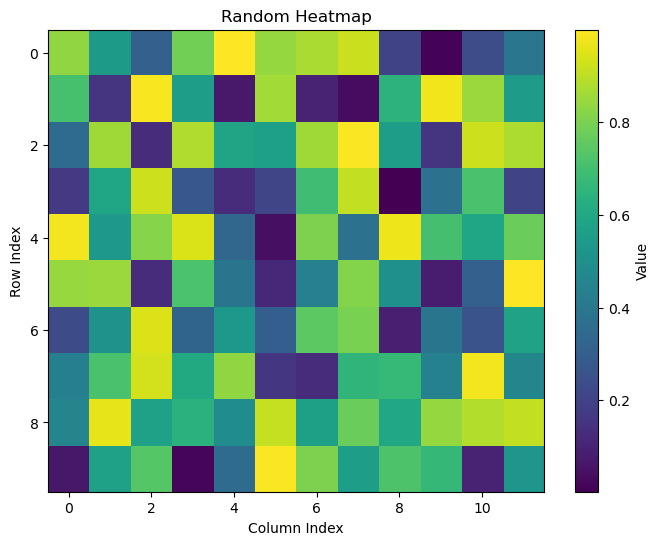

In [20]:
heat_data = np.random.rand(10, 12)

plt.figure(figsize=(8, 6))
plt.imshow(heat_data, cmap='viridis', aspect='auto')
plt.colorbar(label='Value')
plt.title('Random Heatmap')
plt.xlabel('Column Index')
plt.ylabel('Row Index')
plt.show()